# INTRODUCTION

This project analyzes global COVID-19 data to uncover trends in infection rates,recovery rates,mortality and testing efficiency across countries and continents. The goal is to derive actionable insights and demonstrate data analytical skills including data cleaning,transformation,visualization and interpretation.

OBJECTIVES

-Evaluate the recovery and death rates                                                                                                                 
-Assess testing efficiency


DATA DESCRIPTION

This data set includes:
-Country -Continent -Population -Date and time -Cases -Recovered -Deaths -Tests                                                                                                                              

DATA CLEANING

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv(r"C:\Users\luqsu\OneDrive\Desktop\covid_19.csv")

In [3]:
df

,country,continent,population,day,time,Cases,Recovered,Deaths,Tests
0,Saint-Helena,Africa,6115.0,2024-06-30,2024-06-30T16:15:16+00:00,2166,2.0,NaN,NaN
1,Falkland-Islands,South-America,3539.0,2024-06-30,2024-06-30T16:15:16+00:00,1930,1930.0,NaN,8632.0
2,Montserrat,North-America,4965.0,2024-06-30,2024-06-30T16:15:16+00:00,1403,1376.0,8.0,17762.0
3,Diamond-Princess,NaN,NaN,2024-06-30,2024-06-30T16:15:16+00:00,712,699.0,13.0,NaN
4,Vatican-City,Europe,799.0,2024-06-30,2024-06-30T16:15:16+00:00,29,29.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
233,Argentina,South-America,46010234.0,2024-06-30,2024-06-30T16:15:10+00:00,10128845,9997258.0,130841.0,35716069.0
234,Netherlands,Europe,17211447.0,2024-06-30,2024-06-30T16:15:10+00:00,8635786,8612599.0,22992.0,25984435.0
235,Mexico,North-America,131562772.0,2024-06-30,2024-06-30T16:15:10+00:00,7702809,6899865.0,334958.0,20013810.0
236,Iran,Asia,86022837.0,2024-06-30,2024-06-30T16:15:10+00:00,7627186,NaN,146811.0,57320267.0


In [4]:
pd.set_option('display.max.rows',250)
pd.set_option('display.max.columns',10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     238 non-null    object 
 1   continent   236 non-null    object 
 2   population  229 non-null    float64
 3   day         238 non-null    object 
 4   time        238 non-null    object 
 5   Cases       238 non-null    int64  
 6   Recovered   190 non-null    float64
 7   Deaths      233 non-null    float64
 8   Tests       213 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 16.9+ KB


In [6]:
df.count()

country       238
continent     236
population    229
day           238
time          238
Cases         238
Recovered     190
Deaths        233
Tests         213
dtype: int64

In [7]:
df.isnull()

,country,continent,population,day,time,Cases,Recovered,Deaths,Tests
0,False,False,False,False,False,False,False,True,True
1,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False
3,False,True,True,False,False,False,False,False,True
4,False,False,False,False,False,False,False,True,True
5,False,False,False,False,False,False,False,False,True
6,False,True,True,False,False,False,False,False,True
7,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,True,True,True
9,False,False,False,False,False,False,False,False,False


In [8]:
df.isna().sum()

country        0
continent      2
population     9
day            0
time           0
Cases          0
Recovered     48
Deaths         5
Tests         25
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

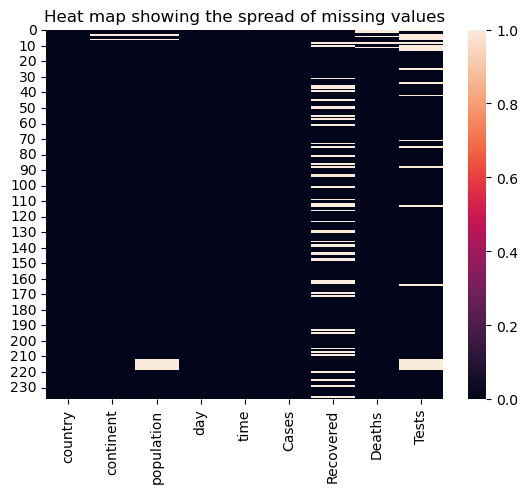

In [9]:
sns.heatmap(df.isna())
plt.title('Heat map showing the spread of missing values')
plt.show 


In [10]:
col_to_fill_with_zero={'Deaths':0,'Tests':0,'Recovered':0,'population':0}

In [11]:
df.fillna(col_to_fill_with_zero,inplace=True) #to fill missing values

In [12]:
df.dropna(subset='continent',inplace=True) #to drop missing values in the continent column as it can not be verified

In [13]:
df.isna().sum()

country       0
continent     0
population    0
day           0
time          0
Cases         0
Recovered     0
Deaths        0
Tests         0
dtype: int64

# FEATURE ENGINEERING

DEATH RATE

In [14]:
df['Death_rate']=df['Deaths']/df['Cases']

In [15]:
df.groupby('continent')['Death_rate'].mean()

continent
Africa           0.019072
All              0.009948
Asia             0.013469
Europe           0.009133
North-America    0.010837
Oceania          0.003332
South-America    0.017783
Name: Death_rate, dtype: float64

RECOVERY RATE

In [16]:
df['Recovery_rate']=df['Recovered']/df['Cases']

In [17]:
df.groupby('continent')['Recovery_rate'].mean()

continent
Africa           0.805784
All              0.958661
Asia             0.731669
Europe           0.744734
North-America    0.667821
Oceania          0.599472
South-America    0.784844
Name: Recovery_rate, dtype: float64

POSITIVITY RATE

In [18]:
df['Positivity_rate']=df['Cases']/df['Tests']

In [19]:
df.replace([np.inf,-np.inf],np.nan,inplace=True)
df.groupby('continent')['Positivity_rate'].mean()

continent
Africa           0.128323
All                   NaN
Asia             0.244042
Europe           0.145169
North-America    0.154734
Oceania          0.261352
South-America    0.253502
Name: Positivity_rate, dtype: float64

# EXPLORATORY DATA ANALYSIS(EDA)

COUNTRIES WITH THE HIGHEST CASES

In [25]:
countries_with_highest_cases=df.groupby('country')['Cases'].mean().sort_values(ascending=False).head(10) 
countries_with_highest_cases

country
All              704753890.0
Europe           253406198.0
Asia             221500265.0
North-America    131889132.0
USA              111820082.0
South-America     70200879.0
India             45035393.0
France            40138560.0
Germany           38828995.0
Brazil            38743918.0
Name: Cases, dtype: float64

COUNTRIES WITH HIGHEST DEATH RATES

In [27]:
countries_with_highest_death_rates=df.groupby('country')['Death_rate'].mean().sort_values(ascending=False).head(10)
countries_with_highest_death_rates

country
Yemen                     0.180745
Western-Sahara            0.100000
Sudan                     0.078852
Syria                     0.054812
Somalia                   0.049791
Peru                      0.048585
Egypt                     0.047697
Mexico                    0.043485
Bosnia-and-Herzegovina    0.040603
Liberia                   0.036465
Name: Death_rate, dtype: float64

COUNTRIES WITH HIGHEST RECOVERY RATES

In [37]:
countries_with_highest_recovery_rates=df.groupby('country')['Recovery_rate'].mean().sort_values(ascending=False).head(10)
countries_with_highest_death_rates

country
Yemen                     0.180745
Western-Sahara            0.100000
Sudan                     0.078852
Syria                     0.054812
Somalia                   0.049791
Peru                      0.048585
Egypt                     0.047697
Mexico                    0.043485
Bosnia-and-Herzegovina    0.040603
Liberia                   0.036465
Name: Death_rate, dtype: float64

COUNTRIES WITH HIGHEST POSITIVITY RATES

In [28]:
countries_with_highest_positivity_rates=df.groupby('country')['Positivity_rate'].mean().sort_values().head(10)
countries_with_highest_positivity_rates

country
China               0.003146
UAE                 0.005316
Turks-and-Caicos    0.010947
Oman                0.015978
Bermuda             0.018319
Saudi-Arabia        0.018501
Rwanda              0.022172
Denmark             0.024617
Bhutan              0.027215
Austria             0.028784
Name: Positivity_rate, dtype: float64

# CHARTS

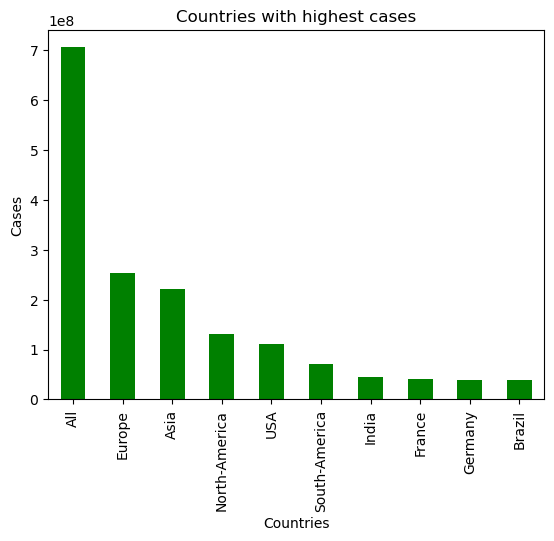

In [32]:
countries_with_highest_cases.plot(kind='bar',color='green')
plt.title('Countries with highest cases')
plt.xlabel('Countries')
plt.ylabel('Cases')
plt.show()

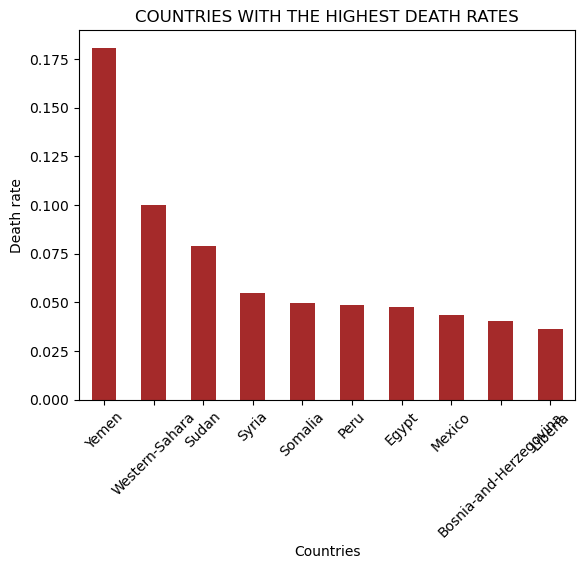

In [47]:
countries_with_highest_death_rates.plot(kind='bar',color='brown')
plt.title('COUNTRIES WITH THE HIGHEST DEATH RATES')
plt.xlabel('Countries')
plt.ylabel('Death rate')
plt.xticks(rotation=45)
plt.show()

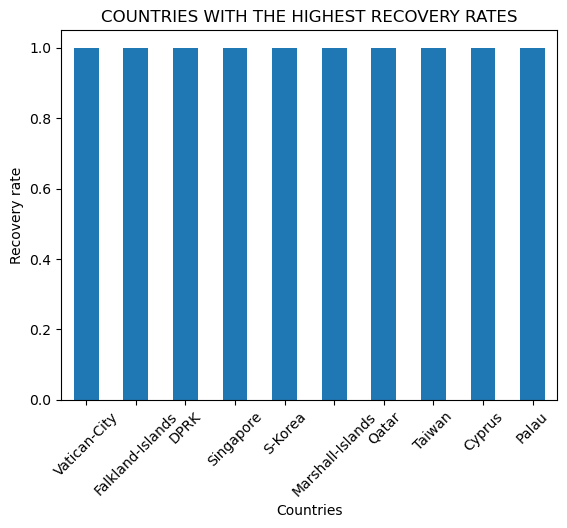

In [45]:

countries_with_highest_recovery_rates.plot(kind='bar')
plt.title('COUNTRIES WITH THE HIGHEST RECOVERY RATES')
plt.xlabel('Countries')
plt.ylabel('Recovery rate')
plt.xticks(rotation=45)
plt.show()

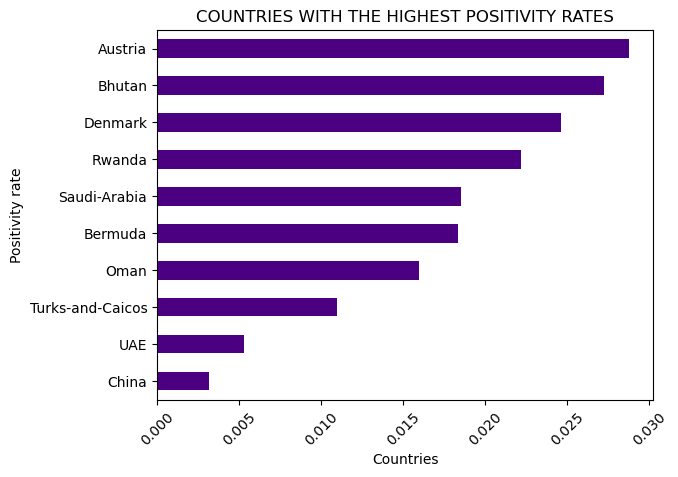

In [46]:
countries_with_highest_positivity_rates.plot(kind='barh',color='indigo')
plt.title('COUNTRIES WITH THE HIGHEST POSITIVITY RATES')
plt.xlabel('Countries')
plt.ylabel('Positivity rate')
plt.xticks(rotation=45)
plt.show()

 CORRELLATION HEATMAP

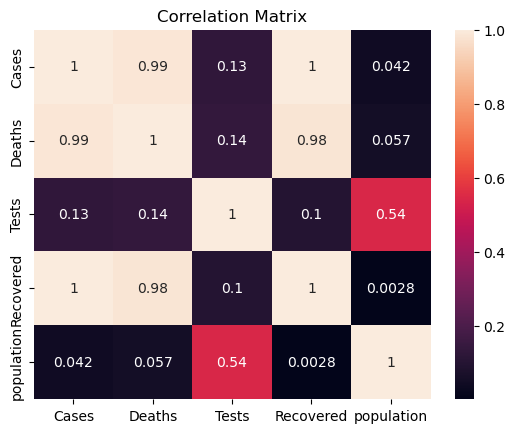

In [56]:
sns.heatmap(df[['Cases','Deaths','Tests','Recovered','population']].corr(),annot=True)
plt.title('Correlation Matrix')
plt.show()

KEY INSIGHT

-Some countries show high case counts but low death rates indicating effective health care systems


In [60]:
df.to_csv("cleaned_covid_data.csv",index=False)